In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

PROCESSED_PATH = "../data/processed"
FIGURES_PATH = "../figures"

In [152]:
df = pd.read_csv(f"{PROCESSED_PATH}/dataset.csv")
df["FECHA_OCURRENCIA"] = pd.to_datetime(df["FECHA_OCURRENCIA"])

df.head()

,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA,DIA_SEMANA_OCURRENCIA,GRAVEDAD,CLASE,LOCALIDAD,latitude,longitude
0,646545,A00410124,306211,2008-09-05 12:50:00,5,CON HERIDOS,ATROPELLO,TEUSAQUILLO,4.655402,-74.101700
1,563782,839933000,291565,2008-05-20 23:40:00,2,SOLO DANOS,CHOQUE,ENGATIVA,4.689417,-74.109351
2,4398952,A000038718,4398952,2014-12-04 17:30:00,4,SOLO DANOS,CHOQUE,ENGATIVA,4.689750,-74.109016
3,1612,726750500,30243,2007-06-29 19:30:00,5,CON HERIDOS,ATROPELLO,PUENTE ARANDA,4.615129,-74.108947
4,569692,840564600,297475,2008-07-21 07:30:00,1,SOLO DANOS,CHOQUE,TEUSAQUILLO,4.646696,-74.108792


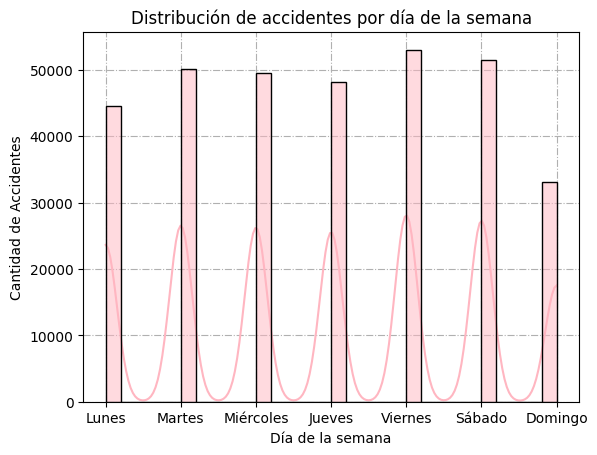

In [14]:
sns.histplot(df, x="DIA_SEMANA_OCURRENCIA", bins=30, zorder = 10, color="lightpink", kde = True)

plt.title("Distribución de accidentes por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de Accidentes")

dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
plt.xticks(ticks=range(1, 8), labels=dias)

plt.grid(linestyle="-.")
plt.savefig(f"{FIGURES_PATH}/accidents_per_day_of_week_histogram.pdf")
plt.show()

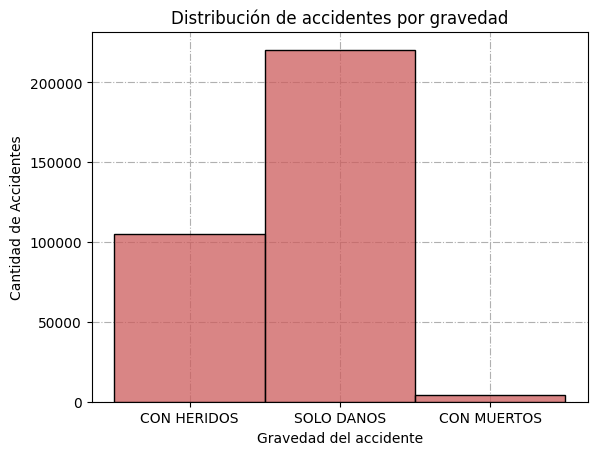

In [15]:
sns.histplot(df, x="GRAVEDAD", zorder = 20, color="indianred")

plt.title("Distribución de accidentes por gravedad")
plt.xlabel("Gravedad del accidente")
plt.ylabel("Cantidad de Accidentes")

plt.grid(linestyle="-.")
plt.savefig(f"{FIGURES_PATH}/accidents_per_gravity_histogram.pdf")
plt.show()

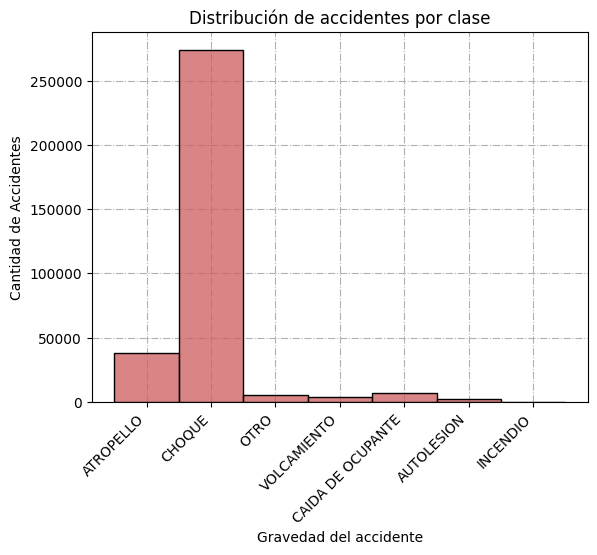

In [16]:
sns.histplot(df, x="CLASE", zorder = 20, color="indianred")

plt.title("Distribución de accidentes por clase")
plt.xlabel("Gravedad del accidente")
plt.ylabel("Cantidad de Accidentes")
plt.xticks(rotation=45, ha="right")

plt.grid(linestyle="-.")
plt.savefig(f"{FIGURES_PATH}/accidents_per_class_histogram.pdf")
plt.show()

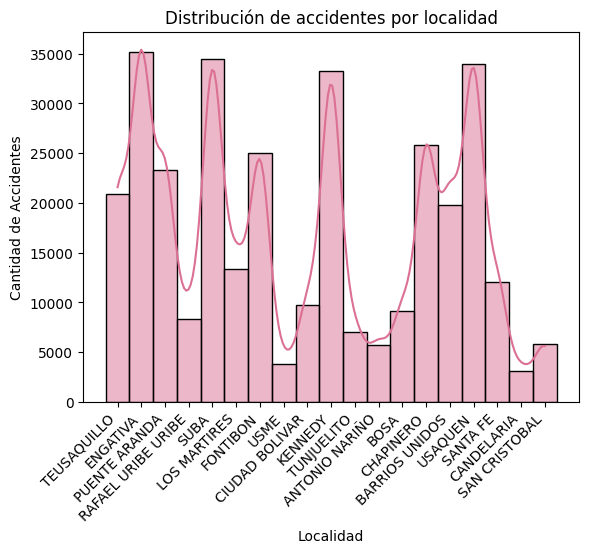

In [21]:
sns.histplot(df, x="LOCALIDAD", color="palevioletred", kde = True)

plt.title("Distribución de accidentes por localidad")
plt.xlabel("Localidad")
plt.ylabel("Cantidad de Accidentes")
plt.xticks(rotation=45, ha="right")

plt.savefig(f"{FIGURES_PATH}/accidents_per_locality_histogram.pdf")
plt.show()

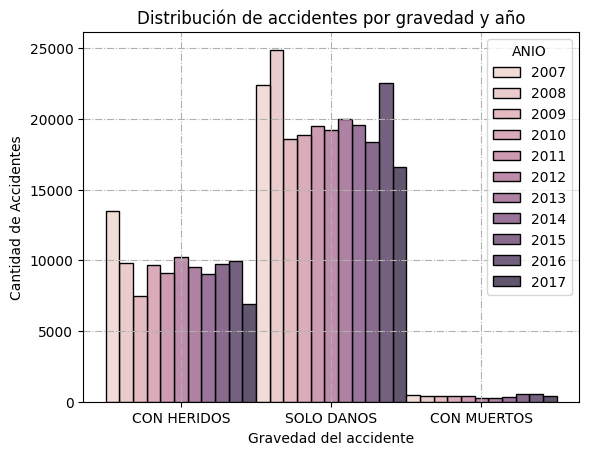

In [153]:
# Cómo varía la gravedad de los accidentes por año
df["ANIO"] = df["FECHA_OCURRENCIA"].dt.year

sns.histplot(data=df, x="GRAVEDAD", hue="ANIO", multiple="dodge")

plt.title("Distribución de accidentes por gravedad y año")
plt.xlabel("Gravedad del accidente")
plt.ylabel("Cantidad de Accidentes")
plt.grid(linestyle="-.")
plt.savefig(f"{FIGURES_PATH}/accidents_per_year_and_gravity_histogram.pdf")
plt.show()


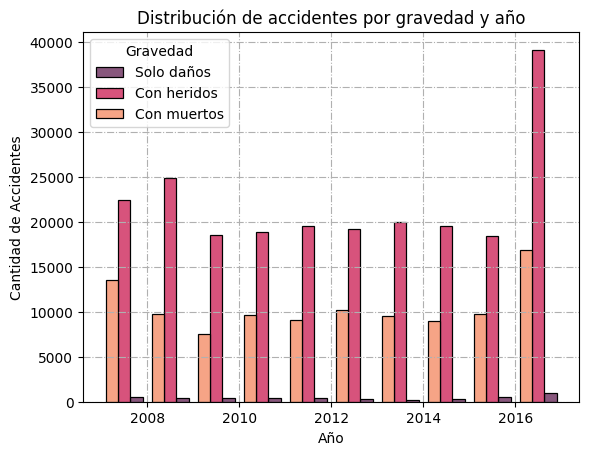

In [154]:
# Evolución de los accidentes por gravedad a lo largo del tiempo.
df["ANIO"] = df["FECHA_OCURRENCIA"].dt.year

sns.histplot(data=df, x="ANIO", hue="GRAVEDAD", multiple="dodge", palette="rocket_r", shrink=0.8, binwidth=1 )

plt.title("Distribución de accidentes por gravedad y año")
plt.xlabel("Año")
plt.ylabel("Cantidad de Accidentes")
plt.legend(title="Gravedad", labels=["Solo daños", "Con heridos", "Con muertos"])
plt.grid(linestyle="-.")
plt.savefig(f"{FIGURES_PATH}/accidents_per_gravity_and_year_histogram.pdf")
plt.show()

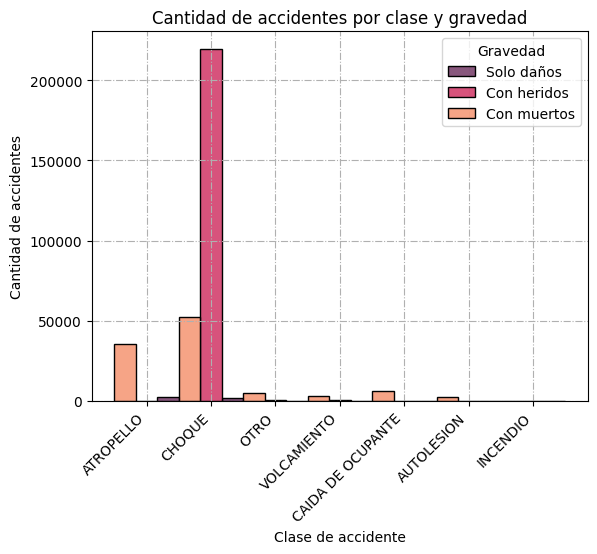

In [155]:
sns.histplot(data=df, x="CLASE", hue="GRAVEDAD", multiple="dodge", palette="rocket_r")

plt.title("Cantidad de accidentes por clase y gravedad")
plt.xlabel("Clase de accidente")
plt.ylabel("Cantidad de accidentes")
plt.xticks(ticks=range(7), rotation=45, ha="right")
plt.grid(linestyle="-.")
plt.legend(title="Gravedad", labels=["Solo daños", "Con heridos", "Con muertos"])
plt.savefig(f"{FIGURES_PATH}/accidents_per_class_and_gravity_histogram.pdf")
plt.show()

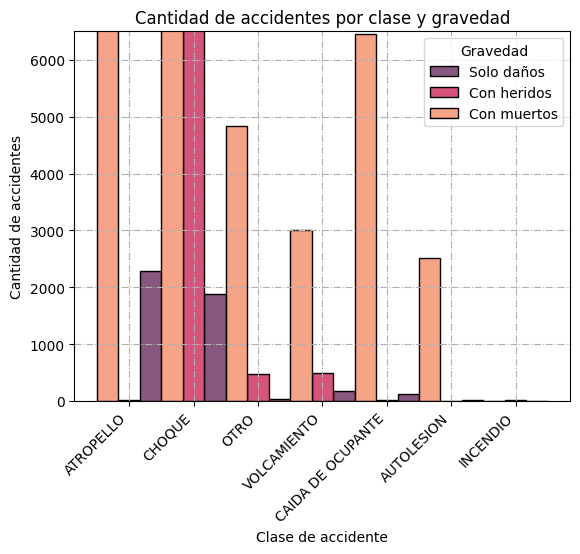

In [140]:
sns.histplot(data=df, x="CLASE", hue="GRAVEDAD", multiple="dodge", palette="rocket_r")

plt.title("Cantidad de accidentes por clase y gravedad")
plt.xlabel("Clase de accidente")
plt.ylabel("Cantidad de accidentes")
plt.xticks(ticks=range(7), rotation=45, ha="right")
plt.grid(linestyle="-.")
plt.legend(title="Gravedad", labels=["Solo daños", "Con heridos", "Con muertos"])
plt.ylim(0, 6500)
plt.show()

In [158]:
GRAVEDAD = {"SOLO DANOS": 0, "CON HERIDOS": 1, "CON MUERTOS": 2}
df["GRAVEDAD"] = df["GRAVEDAD"].apply(lambda gravedad: GRAVEDAD[gravedad])

CLASE = {"ATROPELLO": 0, "CHOQUE": 1, "VOLCAMIENTO": 2, "CAIDA DE OCUPANTE": 3, "AUTOLESION": 4, "INCENDIO": 5, "OTRO": 6}
df["CLASE"] = df["CLASE"].apply(lambda clase: CLASE[clase])

LOCALIDAD = {"TEUSAQUILLO": 0, "ENGATIVA": 1, "PUENTE ARANDA": 2, "RAFAEL URIBE URIBE": 3, "SUBA": 4, 
             "LOS MARTIRES": 5, "FONTIBON": 6, "USME": 7, "CIUDAD BOLIVAR": 8, "KENNEDY": 9, 
             "TUNJUELITO": 10, "ANTONIO NARIÑO": 11, "BOSA": 12, "CHAPINERO": 13, "BARRIOS UNIDOS": 14, 
             "USAQUEN": 15, "SANTA FE": 16, "CANDELARIA": 17, "SAN CRISTOBAL": 18}
df["LOCALIDAD"] = df["LOCALIDAD"].apply(lambda localidad: LOCALIDAD[localidad])

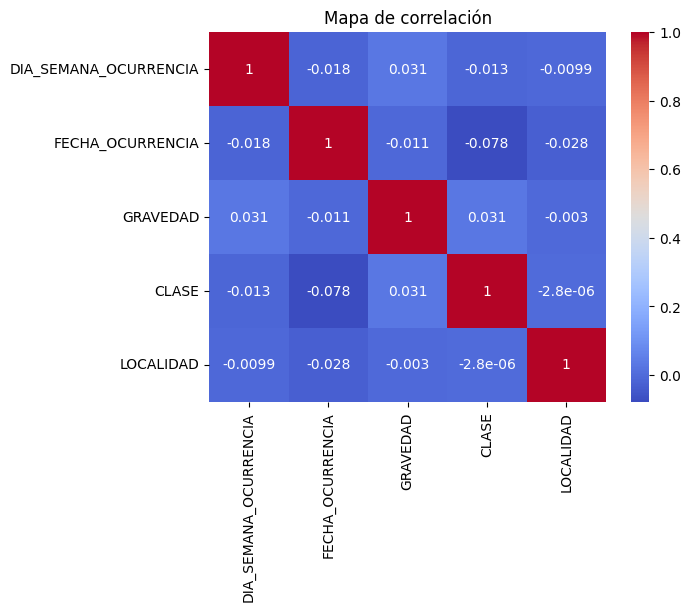

In [161]:
corr = df[["DIA_SEMANA_OCURRENCIA", "FECHA_OCURRENCIA", "GRAVEDAD", "CLASE", "LOCALIDAD"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de correlación")
plt.savefig(f"{FIGURES_PATH}/correlation_map.pdf")
plt.show()